In [1]:
import sys
import os
import subprocess
from pathlib import Path

if 'google.colab' in sys.modules:
    os.environ["OMP_NUM_THREADS"] = "2"
    !pip install -U ipython
    !git clone https://github.com/AdrianPanasiewicz/QML_for_radar_classification.git

    repo_url = "https://github.com/AdrianPanasiewicz/QML_for_radar_classification.git"
    repo_path = "/content/QML_for_radar_classification"
    colab_run_dir = os.path.join(repo_path, 'colab_run')

    def run(cmd, cwd=None):
        return subprocess.check_output(cmd, cwd=cwd, text=True).strip()

    if not os.path.isdir(os.path.join(repo_path, ".git")):
        run(["git", "clone", repo_url, repo_path])
    else:
        run(["git", "fetch", "origin"], cwd=repo_path)
        local_head = run(["git", "rev-parse", "HEAD"], cwd=repo_path)
        remote_head = run(["git", "rev-parse", "origin/HEAD"], cwd=repo_path)
        if local_head != remote_head:
            run(["git", "reset", "--hard", "origin/HEAD"], cwd=repo_path)

    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    os.makedirs(colab_run_dir, exist_ok=True)
    os.chdir(colab_run_dir)

    !pip install -q pennylane
    !pip install "ray[tune]"

    from google.colab import drive
    drive.mount('/content/drive')
    os.environ["RAY_CHDIR_TO_TRIAL_DIR"] = "0"

else:
    os.environ["OMP_NUM_THREADS"] = "12"


%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -ray
%aimport -sklearn

# These import from Data folder are necessary for pickle load to work
from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise
from Data.Primitives.presets import *
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest

from MachineLearning.Processing.file_loader import SyntheticDataFileLoader
from MachineLearning.Processing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Processing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthetic_frequency_dataset import SyntheticFrequencyDomainRadarDataset
from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork
from MachineLearning.Processing.data_visualizer import DataVisualizer
from MachineLearning.Trainers.statistical_trainer import StatisticalTrainer
from MachineLearning.Trainers.hyperparameter_trainer import HyperparameterTrainer

from matplotlib import pyplot as plt
from IPython.display import display, Latex
import numpy as np

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import sympy

import torch
from torch import nn
from torch.nn.functional import normalize
from torch.utils.data import DataLoader
from torch.optim import SGD

import pennylane as qml
import optuna

import ray
from ray import tune
from ray.tune import Checkpoint, CheckpointConfig, RunConfig
from ray.tune.schedulers import ASHAScheduler
import pickle

threads = 8
torch.set_num_threads(threads)
os.environ["OMP_NUM_THREADS"] = str(threads)
os.environ["MKL_NUM_THREADS"] = str(threads)

# Checking preprocessing functionalities

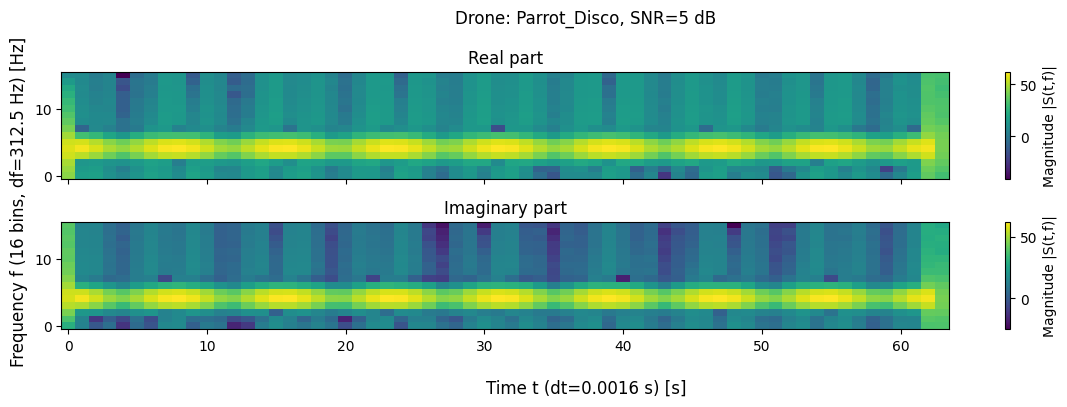

In [39]:
PROJECT_ROOT = Path().cwd().parent
type = "time_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=800)

td_data_parser = TimeDomainDataParser(language='english')
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [4]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

(tensor([1104.3872, 1023.2131,  618.6436, 1458.5701,  798.2772, 1484.0033,
         2003.1965, 2113.1621, 1224.4503, 1042.5212]),
 0,
 DataRequest(request_name='label=DJI_Mavic_Mini', drone=Drone(name='DJI_Mavic_Mini', N=2, L_1=0.005, L_2=0.035, f_rot=160), radar=Radar(λ=0.02998, f_c=9999748432.288193), context=Context(R=1359.141098111902, V_rad=33.521133264997935, θ=1.3149688471789498, Φ_p=0.7381510474892069, A_r=2.2233603189020106, snr=np.int64(-45), t_start=0, t_stop=0.1, dt=0.0001), noise_model=<Data.Primitives.noise_models.AdditiveWhiteGaussianNoise object at 0x0000018520AFF1A0>, sample_size=70))

In [6]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=200)

td_data_parser = FrequencyDomainDataParser()
signal, label, misc_data = td_data_parser.parse_data_object(obj, bin_size=1, return_mag=False)
print(signal.shape)

torch.Size([2, 16, 64])


# Classical Neural Network

## Hyperparameter learner

### Ray search

In [ ]:
try:
    from google.colab import output
    if 'google.colab' in sys.modules:
        IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = Path().cwd().parent
ray.shutdown()

ctx = ray.init(
    _metrics_export_port=8080,
    runtime_env={
        "working_dir": str(PROJECT_ROOT),
        "excludes": [
            "Data/Datasets"
        ]
    }
)

if IN_COLAB:
    print("Loading Ray Dashboard:")
    output.serve_kernel_port_as_iframe(8265, height=600)

    print("Loading Ray Metrics Export:")
    output.serve_kernel_port_as_iframe(8080, height=400)
else:
    print(f"Running locally. Dashboard available at: {ctx.dashboard_url}")
    print("Metrics available at: http://127.0.0.1:8080")

In [ ]:
config_params = 32
divs_array = sympy.divisors(config_params)

pair_map = {div : config_params // div for div in divs_array}


model_config = {
    "layers": tune.grid_search(list(pair_map.keys())),
    "neurons_per_layer": tune.sample_from(lambda config: pair_map[config["model_config"]["layers"]]),
}
training_config = {
	"batch_size": tune.choice([2, 4, 8, 16, 32]),
	"device": "cuda" if torch.cuda.is_available() else "cpu",
	"epochs": 50,
	"optimizer": {
	    "name" : tune.choice(["SGD", "Adam"]),
        "lr": tune.loguniform(1e-5, 1e-1),
        "momentum": tune.uniform(0, 1),
	}
}

config = {
	"model_config": model_config,
	"training_config": training_config,
}


max_num_epochs = training_config["epochs"]
num_trials =  5
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=10,
    reduction_factor=2,
)

cpus_per_trial = 4
gpus_per_trial = 0

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.CrossEntropyLoss()
)


tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=ClassicalNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="accuracy",
        mode="max",
        scheduler=scheduler,
        num_samples=num_trials,
        trial_dirname_creator=lambda trial: f"t_{trial.trial_id}"
    ),
    run_config = RunConfig(
    storage_path= "/content/drive/MyDrive/ray_results" if 'google.colab' in sys.modules else "E:/ray_results",
    checkpoint_config=CheckpointConfig(
            num_to_keep=2,
            checkpoint_score_attribute="accuracy",
            checkpoint_score_order="max",
        ),
    name="radar_hparam_search_cnn",
	),
    param_space=config,
)
results = tuner.fit()

# Current best trial: 8f0ab_00008 with loss=0.4411230981349945 and params={'layers': 1, 'neurons_per_layer': 128, 'lr': 9.763374597090547e-05, 'batch_size': 4, 'device': 'cuda', 'epochs': 250}
# Current best trial: 7a17b_00064 with loss=0.43200549483299255 and params={'layers': 2, 'neurons_per_layer': 32, 'lr': 0.000471644, 'batch_size': 2, 'device': 'cpu', 'epochs': 160}
# 32 params batch size 8	layers 1	0.000148743	250	81.1576	0.493999	0.746429

### Optuna search

In [10]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"


trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion=nn.CrossEntropyLoss()
)

def objective(trial):
    config_params = 1024
    divs_array = sympy.divisors(config_params)

    pair_map = {div : config_params // div for div in divs_array}

    layers = trial.suggest_categorical("layers", list(pair_map.keys()))
    neurons_per_layer = pair_map[layers]

    model_config = {
        "layers": layers,
        "neurons_per_layer": neurons_per_layer,
        "dropout_rate": trial.suggest_float("dropout_rate", 0.0, 0.5)
    }

    training_config = {
    "number_of_training_workers" : 4,
    "number_of_validating_workers" : 2,
    "batch_size": trial.suggest_categorical("batch_size", [2, 4, 8, 16, 32]),
	"device": "cuda" if torch.cuda.is_available() else "cpu",
	"epochs": 20,
	"optimizer": {
	    "name" : trial.suggest_categorical("optimizer_name", ["SGD", "Adam"]),
        "lr": trial.suggest_float("lr", 1e-3, 1e-1, log=True),
        "momentum": trial.suggest_float("momentum", 0.0, 1.0) if trial.params.get("optimizer_name") == "SGD" else 0,
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        },
    "regularization": {
        "type": trial.suggest_categorical("regularization", ["none", "l1", "l2"]),
        "lambda": trial.suggest_float("lambda", 1e-6, 1e-4, log=True),
        },
	}

    config = {
        "model_config" : model_config,
        "training_config" : training_config,
    }

    accuracy = trainer.train_model(trial, config, ClassicalNeuralNetwork)
    return accuracy

pruner = optuna.pruners.HyperbandPruner(
        min_resource=5,
        reduction_factor=2
    )

study = optuna.create_study(direction="maximize", pruner=pruner)
print("Starting Optuna Hyperparameter Search...")

study.optimize(objective, n_trials=100)

print("\n" + "="*50)
print("HYPERPARAMETER SEARCH COMPLETED")
print(f"Best trial final validation accuracy: {study.best_value:.4f}")
print(f"Best trial config: {study.best_params}")
print("="*50)

with open("results.pkl", 'wb') as f:
    pickle.dump(study, f)

[I 2026-04-24 09:58:23,457] A new study created in memory with name: no-name-6fe919a1-6785-4f85-a6f8-19808005df2e


Starting Optuna Hyperparameter Search...


Epochs:   5%|▌         | 1/20 [00:44<14:04, 44.44s/it]
[W 2026-04-24 09:59:07,906] Trial 0 failed with parameters: {'layers': 2, 'dropout_rate': 0.2889512020820284, 'batch_size': 32, 'optimizer_name': 'Adam', 'lr': 0.07225704806367927, 'weight_decay': 4.779460143810969e-06, 'regularization': 'none', 'lambda': 2.1550579325789244e-06} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\adria\miniconda3\envs\Qiskit_workshop\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\adria\AppData\Local\Temp\ipykernel_19104\2288587384.py", line 50, in objective
    accuracy = trainer.train_model(trial, config, ClassicalNeuralNetwork)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification\MachineLearning\Trainers\hyperparameter_traine

KeyboardInterrupt: 

### Statistical learner

In [2]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

model_config = {
    "layers": 4,
    "neurons_per_layer": 128,
    "dropout_rate": 0.2
}

training_config = {
    "number_of_training_workers" : 4,
    "number_of_validating_workers" : 2,
    "number_of_testing_workers" : 2,
    "batch_size": 32,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "epochs": 25,
    'number_of_trials': 5,
    "optimizer": {
        "name" : "Adam",
        "lr": 1e-4,
        "momentum": 0.8,
        "weight_decay": 1e-6
        },
    "regularization": {
        "type": "l1",
        "lambda": 1e-6
        },
}

config = {
    "model_config" : model_config,
    "training_config" : training_config,
}

trainer = StatisticalTrainer(training_path, validating_path, testing_path, criterion = nn.CrossEntropyLoss())
net, metrics_dict = trainer.train_model(ClassicalNeuralNetwork, config)

Model runs: 100%|██████████| 5/5 [01:14<00:00, 14.82s/it]


### Visualization

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Krzywa procesu trenowania'}, xlabel='Epoka', ylabel='Dokładność [%]'>)

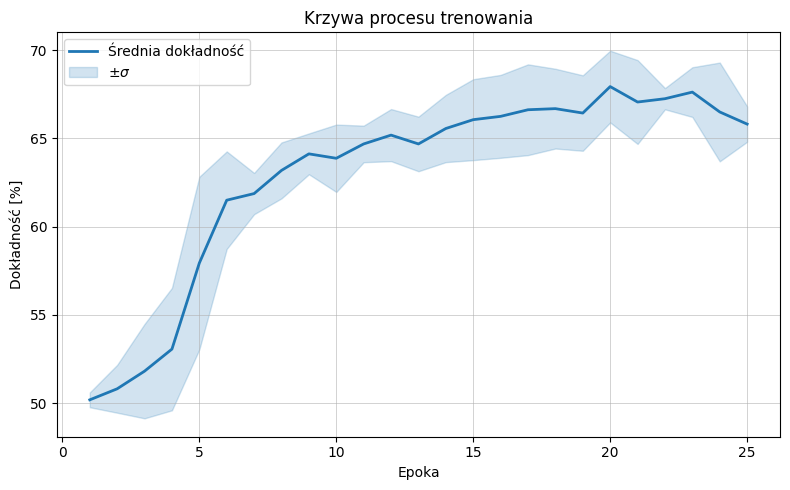

In [3]:
plotter = DataVisualizer(language="polish")
plotter.plot_training_chart(metrics_dict)

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Macierz pomyłek'}, xlabel='Etykieta przewidziana', ylabel='Etykieta rzeczywista'>)

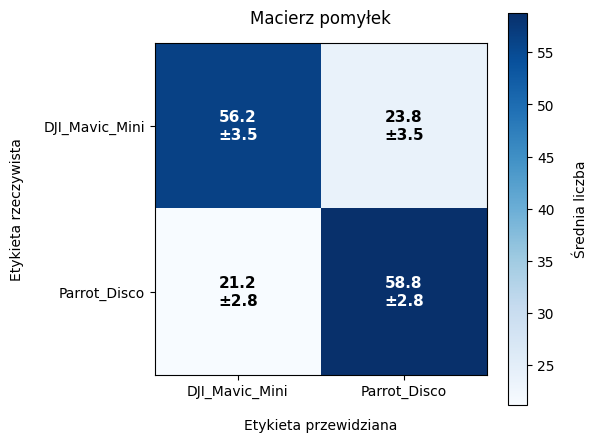

In [4]:
plotter.plot_confusion_matrix(metrics_dict, significant_digits=1)

In [5]:
display(plotter.get_metrics_table(metrics_dict, significant_digits=3))

Metryka,Wartość oczekiwana ± Odchylenie standardowe
Dokładność,0.719 ± 0.009
Zbalansowana dokładność,0.719 ± 0.009
Macro-Precyzja,0.720 ± 0.009
Macro-Czułość,0.719 ± 0.009
Macro-Wynik F1,0.718 ± 0.009


# Quantum Neural Network

## Hyperparameter learner

### Ray searcher

In [ ]:
try:
    from google.colab import output
    if 'google.colab' in sys.modules:
        IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = Path().cwd().parent
ray.shutdown()

ctx = ray.init(
    _metrics_export_port=8080,
    runtime_env={
        "working_dir": str(PROJECT_ROOT),
        "excludes": [
            "Data/Datasets"
        ]
    }
)

if IN_COLAB:
    print("Loading Ray Dashboard:")
    output.serve_kernel_port_as_iframe(8265, height=600)

    print("Loading Ray Metrics Export:")
    output.serve_kernel_port_as_iframe(8080, height=400)
else:
    print(f"Running locally. Dashboard available at: {ctx.dashboard_url}")
    print("Metrics available at: http://127.0.0.1:8080")

In [ ]:
model_config = {
    "n_qubits"  : 10,
    "layers"    : tune.choice([1,2,3,4,5]),
    "encoding"  : tune.choice(["angle", "amplitude"]),
    "ansatz"    : tune.choice(["basic", "entangling", "random"]),
    "simulator" : 'default.qubit',
}
training_config = {
	"batch_size": tune.choice([2, 4, 8, 16, 32]),
	"device": "cpu",
	"epochs": 50,
	"optimizer": {
	    "name" : tune.choice(["SGD", "Adam"]),
        "lr": tune.loguniform(1e-5, 1e-1),
        "momentum": tune.uniform(0, 1),
        "weight_decay": tune.loguniform(1e-6, 1e-3),
	}
}

config = {
	"model_config": model_config,
	"training_config": training_config,
}

max_num_epochs = training_config["epochs"]
num_trials =  100
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=10,
    reduction_factor=2,
)

cpus_per_trial = 12
gpus_per_trial = 0

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.BCELoss()
)

tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=QuantumNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="accuracy",
        mode="max",
        scheduler=scheduler,
        num_samples=num_trials,
        trial_dirname_creator=lambda trial: f"t_{trial.trial_id}"
    ),
    run_config = RunConfig(
    storage_path= "/content/drive/MyDrive/ray_results" if 'google.colab' in sys.modules else "E:/ray_results",
    checkpoint_config=CheckpointConfig(
            num_to_keep=2,
            checkpoint_score_attribute="accuracy",
            checkpoint_score_order="max",
        ),
    name="radar_hparam_search_qnn",
    verbose=1
	),
    param_space=config,
)
results = tuner.fit()

### Optuna seach

In [4]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion=nn.BCELoss()
)

def objective(trial):
    model_config = {
        "n_qubits": 10,
        "layers": trial.suggest_int("layers", 1, 5),
        "encoding": trial.suggest_categorical("encoding", ["angle", "amplitude"]),
        "ansatz": trial.suggest_categorical("ansatz", ["basic", "entangling", "random"]),
        "simulator": "default.qubit",
    }

    training_config = {
    "number_of_training_workers" : 4,
    "number_of_validating_workers" : 2,
    "number_of_testing_workers" : 2,
    "batch_size": trial.suggest_categorical("batch_size", [2, 4, 8, 16, 32]),
	"device": "cpu",
	"epochs": 20,
	"optimizer": {
	    "name" : trial.suggest_categorical("optimizer_name", ["SGD", "Adam"]),
        "lr": trial.suggest_float("lr", 1e-3, 1e-1, log=True),
        "momentum": trial.suggest_float("momentum", 0.0, 1.0) if trial.params.get("optimizer_name") == "SGD" else 0,
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        },
    "regularization": {
        "type": None,
        "lambda": None,
        },
	}

    config = {
        "model_config" : model_config,
        "training_config" : training_config,
    }

    accuracy = trainer.train_model(trial, config, QuantumNeuralNetwork)
    return accuracy

pruner = optuna.pruners.HyperbandPruner(
        min_resource=5,
        reduction_factor=2
    )

study = optuna.create_study(direction="maximize", pruner=pruner)
print("Starting Optuna Hyperparameter Search...")

study.optimize(objective, n_trials=100)

print("\n" + "="*50)
print("HYPERPARAMETER SEARCH COMPLETED")
print(f"Best trial final validation accuracy: {study.best_value:.4f}")
print(f"Best trial config: {study.best_params}")
print("="*50)

# [I 2026-04-23 19:03:28,113] Trial 7 finished with value: 0.6428571428571429 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.0010560909021002144, 'weight_decay': 1.590794237146988e-06}. Best is trial 7 with value: 0.6428571428571429.
# [I 2026-04-24 10:39:02,015] Trial 10 finished with value: 0.6678571428571428 and parameters: {'layers': 5, 'encoding': 'amplitude', 'ansatz': 'entangling', 'batch_size': 8, 'optimizer_name': 'Adam', 'lr': 0.008544783066140834, 'weight_decay': 1.0107494881244923e-06}. Best is trial 10 with value: 0.6678571428571428.

[I 2026-04-24 10:07:51,769] A new study created in memory with name: no-name-7a055d95-2aa1-4cde-ad16-3117806c05db


Starting Optuna Hyperparameter Search...


Epochs: 100%|██████████| 20/20 [03:17<00:00,  9.88s/it]
[I 2026-04-24 10:11:10,802] Trial 0 finished with value: 0.4928571428571429 and parameters: {'layers': 1, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 4, 'optimizer_name': 'Adam', 'lr': 0.06359192611641255, 'weight_decay': 1.0801680531457076e-05}. Best is trial 0 with value: 0.4928571428571429.
Epochs: 100%|██████████| 20/20 [03:24<00:00, 10.21s/it]
[I 2026-04-24 10:14:36,449] Trial 1 finished with value: 0.525 and parameters: {'layers': 2, 'encoding': 'angle', 'ansatz': 'basic', 'batch_size': 4, 'optimizer_name': 'SGD', 'lr': 0.003913125693784849, 'momentum': 0.9580389963797324, 'weight_decay': 3.892297014645386e-05}. Best is trial 1 with value: 0.525.
Epochs: 100%|██████████| 20/20 [02:18<00:00,  6.92s/it]
[I 2026-04-24 10:16:56,311] Trial 2 finished with value: 0.6142857142857143 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 32, 'optimizer_name': 'Adam', 'lr': 0.020861355


HYPERPARAMETER SEARCH COMPLETED
Best trial final validation accuracy: 0.6679
Best trial config: {'layers': 5, 'encoding': 'amplitude', 'ansatz': 'entangling', 'batch_size': 8, 'optimizer_name': 'Adam', 'lr': 0.008544783066140834, 'weight_decay': 1.0107494881244923e-06}


In [5]:
import pickle
with open("qnn_results.pkl", 'wb') as f:
    pickle.dump(study, f)

### Statistical learner

C:\Users\adria\AppData\Local\Temp\ipykernel_1352\2074594312.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


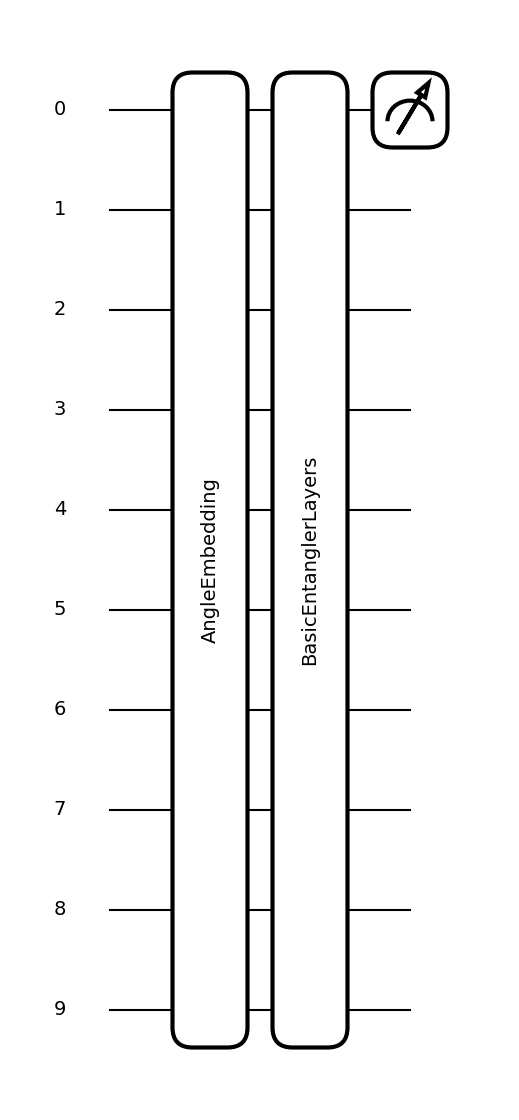

In [95]:
model_config = {
    "n_qubits"  : 4,
    "layers"    : 2,
    "encoding"  : "angle",
    "ansatz"    : "basic",
    "simulator" : 'default.qubit',
}

qnn = QuantumNeuralNetwork(model_config)

x = torch.randn(4)

y = qnn.qnode(x)
fig, ax = qml.draw_mpl(qnn.qnode)(x)
fig.show()

In [4]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

model_config = {
    "n_qubits"  : 10,
    "layers"    : 2,
    "encoding"  : "angle",
    "ansatz"    : "basic",
    "simulator" : 'default.qubit',
}

training_config = {
    "number_of_training_workers" : 4,
    "number_of_validating_workers" : 2,
    "number_of_testing_workers" : 2,
    "batch_size": 32,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "epochs": 100,
    'number_of_trials': 10,
    "optimizer": {
        "name" : "Adam",
        "lr": 1e-4,
        "momentum": 0.8,
        "weight_decay": 1e-6
        },
    "regularization": {
        "type": "l1",
        "lambda": 1e-6
        },
}
config = {
    "model_config" : model_config,
    "training_config" : training_config,
}

trainer = StatisticalTrainer(training_path, validating_path, testing_path, criterion=nn.BCELoss())
net, metrics_dict_qnn = trainer.train_model(QuantumNeuralNetwork, config)

Model runs: 100%|██████████| 10/10 [41:58<00:00, 251.89s/it]


### Visualize data

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Model Accuracy During Training'}, xlabel='Epoch', ylabel='Accuracy [%]'>)

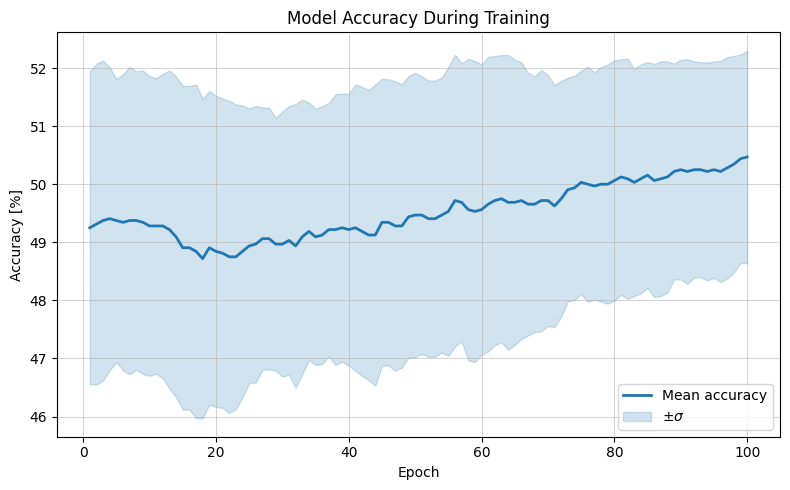

In [8]:
plotter = DataVisualizer(language="english")
plotter.plot_training_chart(metrics_dict_qnn)

(<Figure size 600x500 with 2 Axes>,
 <Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

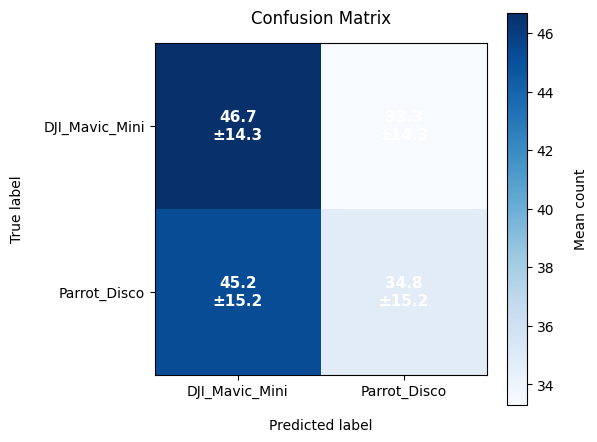

In [6]:
plotter.plot_confusion_matrix(metrics_dict_qnn, significant_digits=1)

In [7]:
plotter.get_metrics_table(metrics_dict_qnn, significant_digits=3)

Metric,Expectation value ± Standard deviation
Accuracy,0.509 ± 0.038
Balanced accuracy,0.509 ± 0.038
Precision,0.507 ± 0.052
Recall,0.435 ± 0.190
F1-score,0.451 ± 0.123
